In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [149]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['target_instances', 'd', 'seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['d', 'target_instances'], group_keys=False).head(k)
    topk_d = topk_df[['d', 'target_instances', 'method', 'rmse', 'mae']]
    return topk_d, topk_df




<Axes: xlabel='d', ylabel='rmse'>

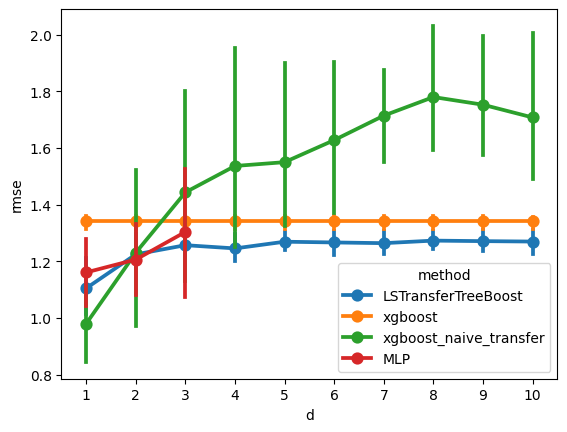

In [161]:
best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    f'../results/LSTransferTreeBoost_ablation_friedman.csv',
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)
data = pd.read_csv('results/xgboost_ablation_friedman.csv')
xgboost_data = data[data['method'] == 'xgboost']
naive_transfer_data = data[data['method'] != 'xgboost']

best_XGBoost, _ = topk_per_d_per_method(
    xgboost_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)

best_naive_transfer, _ = topk_per_d_per_method(
    naive_transfer_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)


best_mlp, _ = topk_per_d_per_method(
    f'../results/MLP_ablation_friedman.csv',
['target_instances', 'd', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
)

best_tradaboost, _ = topk_per_d_per_method(
    f'results/tradaboost_ablation_friedman.csv',
['target_instances', 'd', 'n_estimators','lr','tree_size'], k=5
)

df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_naive_transfer])
df = pd.concat([df, best_mlp])
df = pd.concat([df, best_tradaboost])
sns.pointplot(data = df[df['target_instances'] == 300], x = 'd', y = 'rmse', hue = 'method')




In [151]:
best_params_for_us

,target_instances,d,v,source_tree_size,target_tree_size,m_0,k,avg_rmse,avg_mae,n_seeds,seed,method,val_rmse,val_mae,rmse,mae
3225,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,1,LSTransferTreeBoost,1.068126,0.837024,1.075921,0.844770
3321,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,4,LSTransferTreeBoost,1.015718,0.790704,1.006120,0.789023
3257,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,2,LSTransferTreeBoost,1.292635,1.015985,1.301308,1.025037
3353,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,5,LSTransferTreeBoost,1.220868,0.964870,1.154014,0.911733
3289,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,3,LSTransferTreeBoost,1.037696,0.830100,0.987166,0.790522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499,100,10,0.1,2,1,0.9,0.05,1.913033,1.522366,5,2,LSTransferTreeBoost,1.728180,1.383653,1.794042,1.422162
1531,100,10,0.1,2,1,0.9,0.05,1.913033,1.522366,5,3,LSTransferTreeBoost,2.013109,1.612986,1.946269,1.592927
1595,100,10,0.1,2,1,0.9,0.05,1.913033,1.522366,5,5,LSTransferTreeBoost,1.805269,1.402929,1.735189,1.337689
1563,100,10,0.1,2,1,0.9,0.05,1.913033,1.522366,5,4,LSTransferTreeBoost,2.020507,1.613152,2.019286,1.630191


In [43]:
top3_mlp = topk_per_d_per_method(
    f'results/MLP_ablation_{train_size}.csv',
    param_cols=['d', 'method', 'base_lr', 'fine_tuning_lr', 'dropout_rate', 'batch_norm'],
    k=1
)
print("Top 3 per d — MLP finetuning:\n")
top3_mlp

Top 3 per d — MLP finetuning:



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27544\2828551223.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(k, 'avg_rmse'))


,d,method,base_lr,fine_tuning_lr,dropout_rate,batch_norm,avg_rmse,avg_mae,n_seeds
0,2,MLP,0.0001,0.0001,0.0,False,1.557936,1.234073,5
1,4,MLP,0.0001,0.0001,0.0,False,1.720525,1.373093,5
2,6,MLP,0.0005,0.0001,0.0,False,1.791911,1.445321,5


In [44]:
top3_transfer = topk_per_d_per_method(
    f'results/LSTransferTreeBoost_ablation_{train_size}.csv',
    param_cols=['d', 'method', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'],
    k=1
)
print("Top 3 per d — TransferTreeBoost:\n")
top3_transfer

Top 3 per d — TransferTreeBoost:



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27544\2828551223.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(k, 'avg_rmse'))


,d,method,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds
0,2,LSTransferTreeBoost,0.05,2,1,0.01,0.9,1.546547,1.228191,5
1,4,LSTransferTreeBoost,0.10,2,1,0.01,0.9,1.606551,1.278412,5
2,6,LSTransferTreeBoost,0.10,2,1,0.05,0.5,1.639586,1.298222,5


In [45]:
df = pd.concat((top3_xgb_plain[['d','method', 'avg_rmse', 'avg_mae']], top3_xgb_naive[['d','method', 'avg_rmse', 'avg_mae']]))
df = pd.concat((df, top3_mlp[['d','method', 'avg_rmse', 'avg_mae']]))
df = pd.concat((df, top3_transfer[['d','method', 'avg_rmse', 'avg_mae']]))

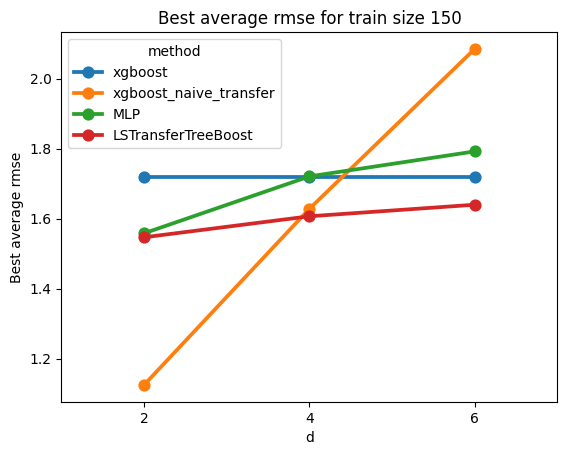

In [46]:
sns.pointplot(data=df, x='d', y='avg_rmse', hue = 'method')
plt.ylabel('Best average rmse')
plt.title('Best average rmse for train size 150')
plt.savefig('friedman.png')